# Ships Sent Analysis

Loads all winning replay episodes and builds a dataframe of every fleet-dispatch action:
- `episode` — episode ID
- `timestep` — step within the episode
- `ships_sent` — ships dispatched (action[2])
- `ships_src` — ships on the source planet at the time of dispatch

In [1]:
import json
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPLAY_DIR = Path("110-replays/53402535")
replay_files = sorted(REPLAY_DIR.glob("episode_*.json"))
print(f"Found {len(replay_files)} replay files")

Found 542 replay files


In [2]:
rows = []

for fpath in replay_files:
    ep_id = int(fpath.stem.split("_")[1])
    with open(fpath, encoding="utf-8") as f:
        ep = json.load(f)

    steps = ep["steps"]
    for step in steps:
        for agent_step in step:
            actions = agent_step.get("action") or []
            if not actions:
                continue
            obs = agent_step.get("observation", {})
            planets = obs.get("planets", [])
            # Build planet ship lookup: planet_id -> ships
            planet_ships = {int(p[0]): p[5] for p in planets}
            timestep = obs.get("step", 0)

            for action in actions:
                src_id = int(action[0])
                ships_sent = action[2]
                ships_src = planet_ships.get(src_id, float("nan"))
                rows.append({
                    "episode": ep_id,
                    "timestep": timestep,
                    "ships_sent": ships_sent,
                    "ships_src": ships_src,
                })

df = pd.DataFrame(rows)
print(f"Total actions: {len(df):,}")
df.head(10)

Total actions: 452,170


,episode,timestep,ships_sent,ships_src
0,78867640,12,21.0,1.0
1,78867640,0,21.0,1.0
2,78867640,15,3.0,1.0
3,78867640,0,3.0,1.0
4,78867640,18,3.0,1.0
5,78867640,0,3.0,1.0
6,78867640,20,22.0,6.0
7,78867640,0,22.0,6.0
8,78867640,21,3.0,1.0
9,78867640,0,3.0,1.0


In [3]:
df["ratio"] = df["ships_sent"] / df["ships_src"]
df.describe()

,episode,timestep,ships_sent,ships_src,ratio
count,4.521700e+05,452170.000000,452170.000000,451301.000000,4.513010e+05
mean,7.905902e+07,116.028684,49.500020,28.745221,inf
std,1.290282e+05,161.205884,69.383661,80.706258,NaN
min,7.886764e+07,0.000000,0.000000,0.000000,1.237624e-03
25%,7.892888e+07,0.000000,8.000000,2.000000,1.000000e+00
50%,7.905595e+07,0.000000,27.000000,4.000000,4.000000e+00
75%,7.917235e+07,238.000000,67.000000,15.000000,1.300000e+01
max,7.932007e+07,499.000000,2254.000000,3473.000000,inf


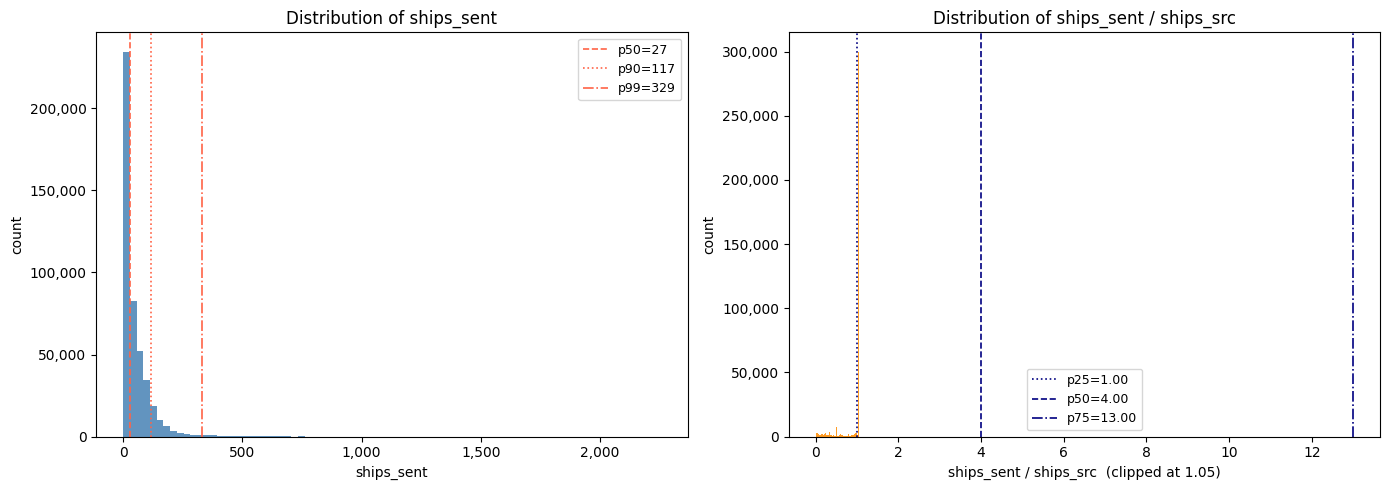

Saved 115-ships_sent_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ships_sent distribution ---
ax = axes[0]
ax.hist(df["ships_sent"], bins=80, color="steelblue", edgecolor="none", alpha=0.85)
ax.set_xlabel("ships_sent")
ax.set_ylabel("count")
ax.set_title("Distribution of ships_sent")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Percentile lines
for p, ls in [(50, "--"), (90, ":"), (99, "-.")]:
    v = np.percentile(df["ships_sent"].dropna(), p)
    ax.axvline(v, color="tomato", linestyle=ls, linewidth=1.2, label=f"p{p}={v:.0f}")
ax.legend(fontsize=9)

# --- ships_sent / ships_src distribution ---
ax2 = axes[1]
ratio_clean = df["ratio"].replace([np.inf, -np.inf], np.nan).dropna()
ratio_clipped = ratio_clean.clip(upper=1.05)
ax2.hist(ratio_clipped, bins=80, color="darkorange", edgecolor="none", alpha=0.85)
ax2.set_xlabel("ships_sent / ships_src  (clipped at 1.05)")
ax2.set_ylabel("count")
ax2.set_title("Distribution of ships_sent / ships_src")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for p, ls in [(25, ":"), (50, "--"), (75, "-.")]:
    v = np.percentile(ratio_clean, p)
    ax2.axvline(v, color="navy", linestyle=ls, linewidth=1.2, label=f"p{p}={v:.2f}")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("115-ships_sent_distribution.png", dpi=150)
plt.show()
print("Saved 115-ships_sent_distribution.png")

In [5]:
# Quantile table for ships_sent and ratio
quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
summary = pd.DataFrame({
    "ships_sent": df["ships_sent"].quantile(quantiles).values,
    "ratio (ships_sent/ships_src)": ratio_clean.quantile(quantiles).values,
}, index=[f"p{int(q*100)}" for q in quantiles])
summary

,ships_sent,ratio (ships_sent/ships_src)
p1,1.0,0.022556
p5,1.0,0.142857
p10,2.0,0.333333
p25,8.0,1.000000
p50,27.0,4.000000
p75,67.0,13.000000
p90,117.0,29.000000
p95,162.0,45.000000
p99,329.0,110.000000


# Graph log exp

In [13]:
df["ships_sent"]/df["ships_sent"].max()

0         0.009317
1         0.009317
2         0.001331
3         0.001331
4         0.001331
            ...   
452165    0.027507
452166    0.034161
452167    0.032387
452168    0.028838
452169    0.035492
Name: ships_sent, Length: 452170, dtype: float64

In [ ]:
(
    df["ships_sent"]
    .value_counts()
    .plot()
)

ships_sent
1.0       37036
2.0       16860
3.0       14244
5.0       13058
4.0       12142
          ...  
1210.0        1
1611.0        1
1340.0        1
733.0         1
985.0         1
Name: count, Length: 951, dtype: int64

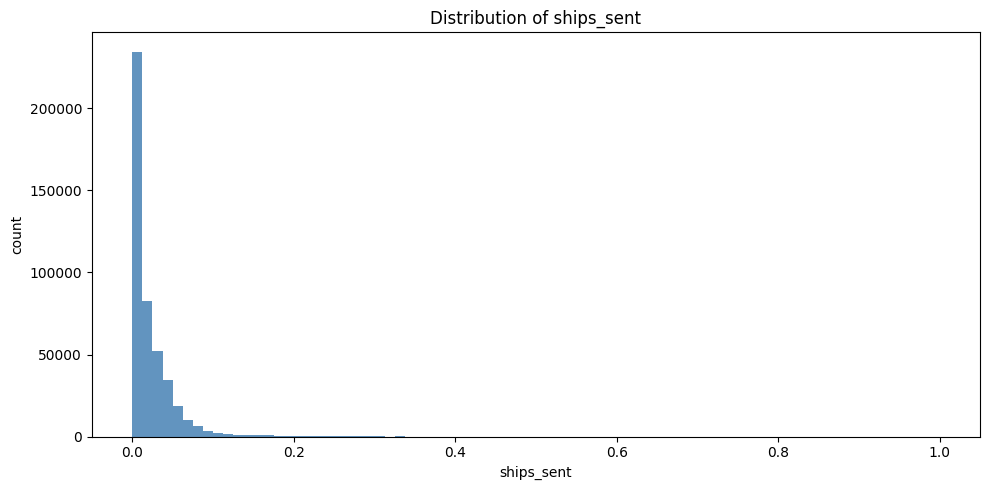

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- ships_sent distribution ---
ax.hist(df["ships_sent"]/df["ships_sent"].max(), bins=80, color="steelblue", edgecolor="none", alpha=0.85)
ax.set_xlabel("ships_sent")
ax.set_ylabel("count")
ax.set_title("Distribution of ships_sent")
# ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
# ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("ships_sent_log_exp.png", dpi=150)
plt.show()